<a href="https://colab.research.google.com/github/sushilsayshello/Account/blob/main/IEEE_Version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

In [5]:
# Step 1: Load and preprocess the dataset
data = pd.read_csv('RT_IOT2022.csv')  # Replace with your dataset path

# Select features and target
X = data.drop(['Attack_type', 'Unnamed: 0'], axis=1)
y = data['Attack_type']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['proto', 'service'], drop_first=True)

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Binarize y_test for multiclass ROC
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

In [6]:
# Step 2: Define and train models
models = {
    "XGBoost": XGBClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SGD": SGDClassifier(loss="log_loss"),
    "Naive Bayes": GaussianNB()
}

# Train all models
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [7]:
# Step 3: Evaluate models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
        'AUC': None
    }
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)
        metrics['AUC'] = roc_auc_score(y_test_binarized, y_pred_proba, multi_class="ovr")
    return metrics

# Collect metrics for all models
results = {}
for name, model in trained_models.items():
    results[name] = evaluate_model(model, X_test, y_test)

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<ipython-input-8-7caccdae29e3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette="viridis")


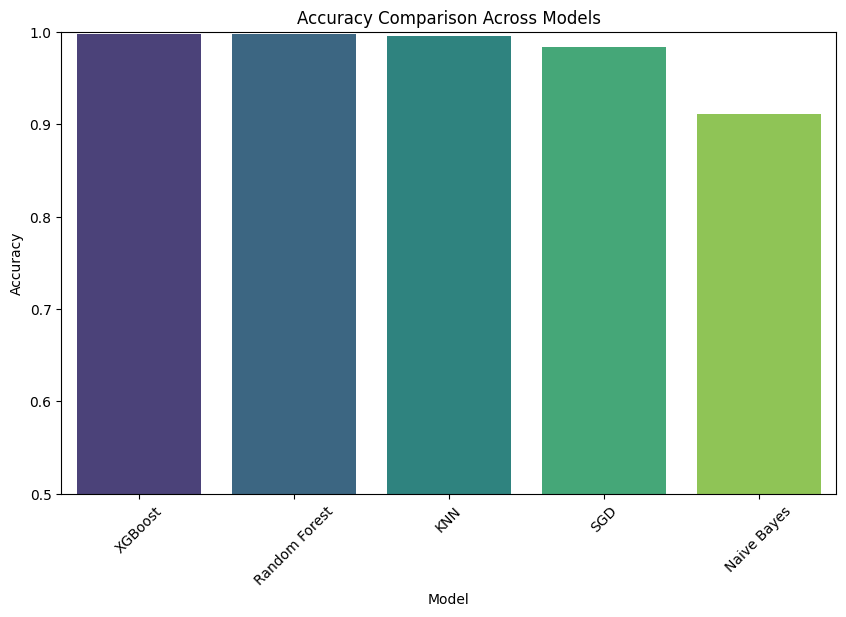

<ipython-input-8-7caccdae29e3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette="viridis")


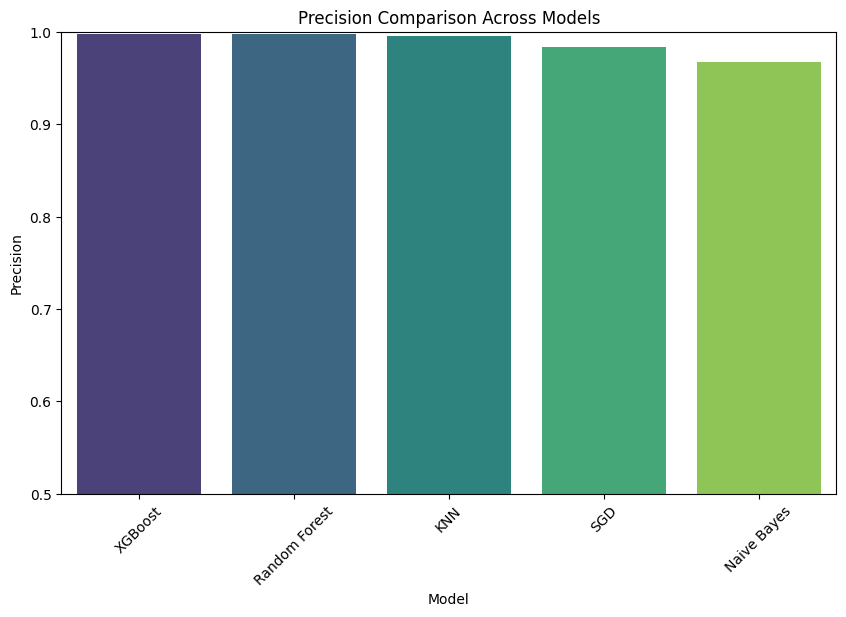

<ipython-input-8-7caccdae29e3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette="viridis")


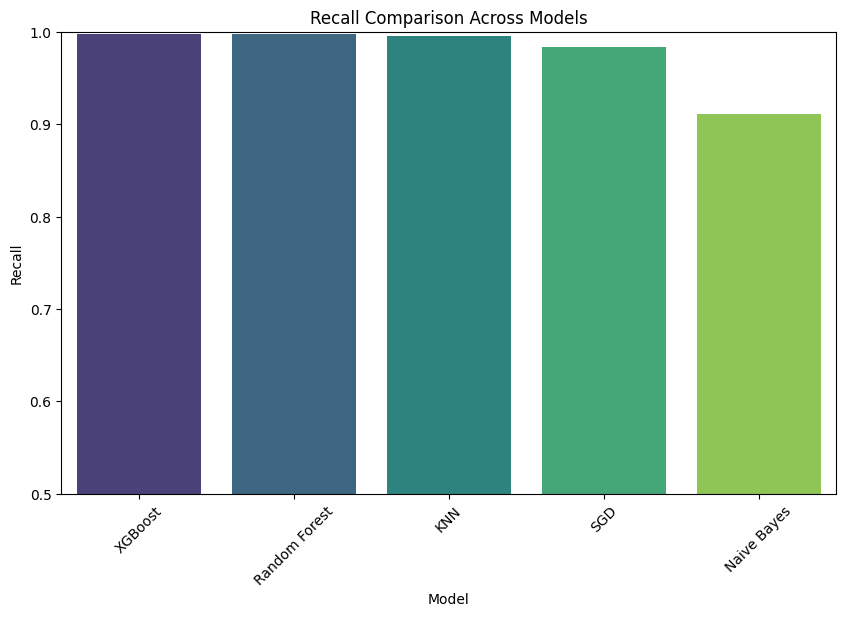

<ipython-input-8-7caccdae29e3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette="viridis")


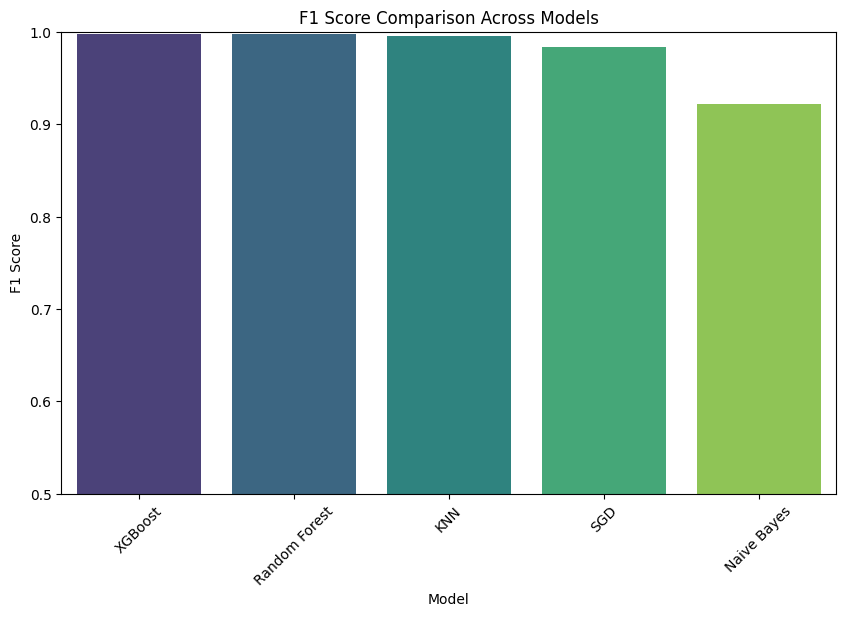

<ipython-input-8-7caccdae29e3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette="viridis")


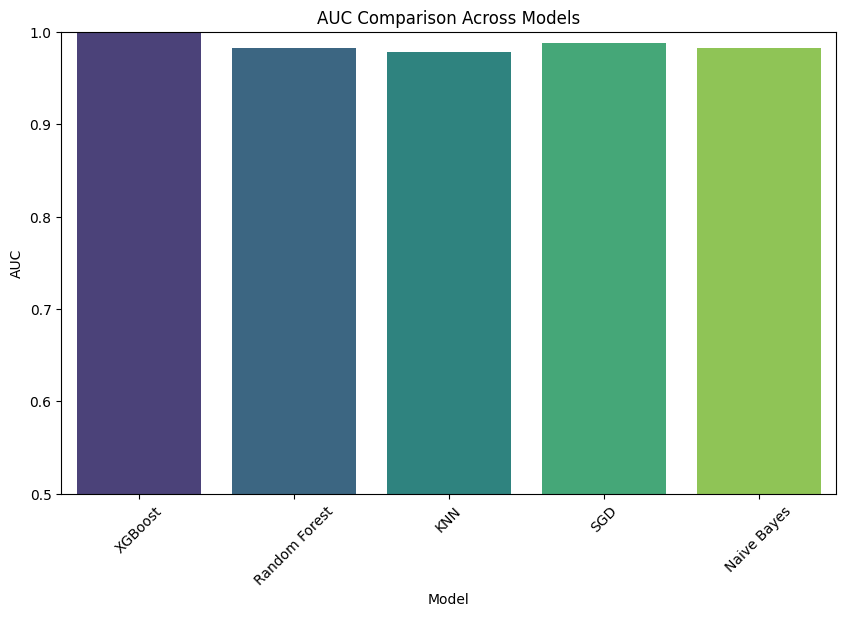

In [8]:
# Step 4: Visualize performance metrics
# Bar plot for overall metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Model', y=metric, data=results_df, palette="viridis")
    plt.title(f"{metric} Comparison Across Models")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.ylim(0.5, 1.0)  # Adjust as needed
    plt.xticks(rotation=45)
    plt.show()


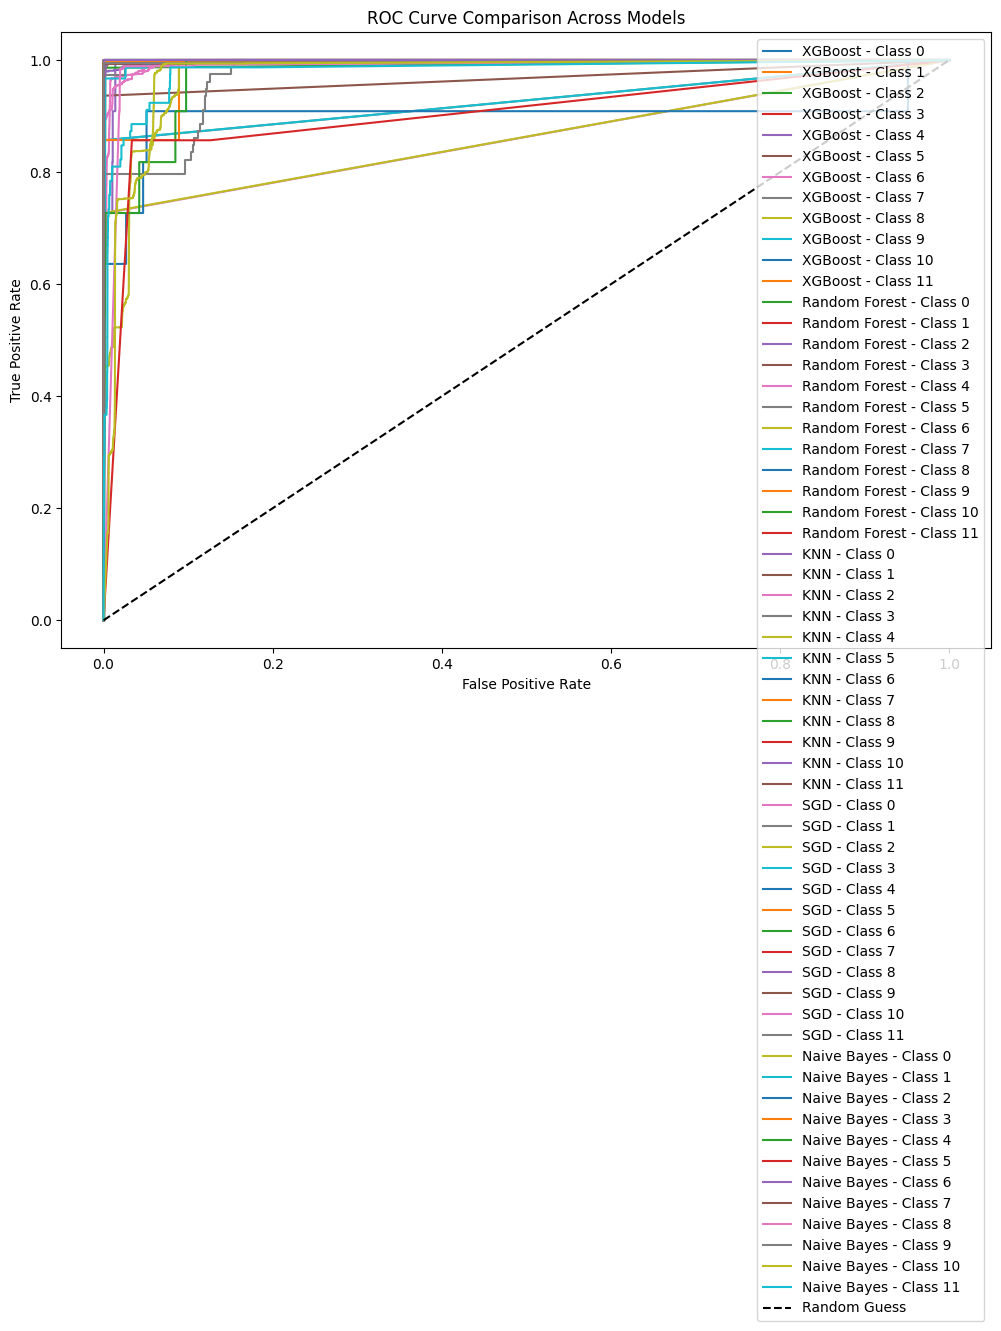

In [9]:
# Step 5: ROC curves for models
plt.figure(figsize=(12, 8))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)
        for i in range(y_test_binarized.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f"{name} - Class {i}")
    else:
        print(f"{name} does not support predict_proba; skipping ROC curve.")

# Plot diagonal random guess line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

# Add titles and labels
plt.title("ROC Curve Comparison Across Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="best")
plt.show()

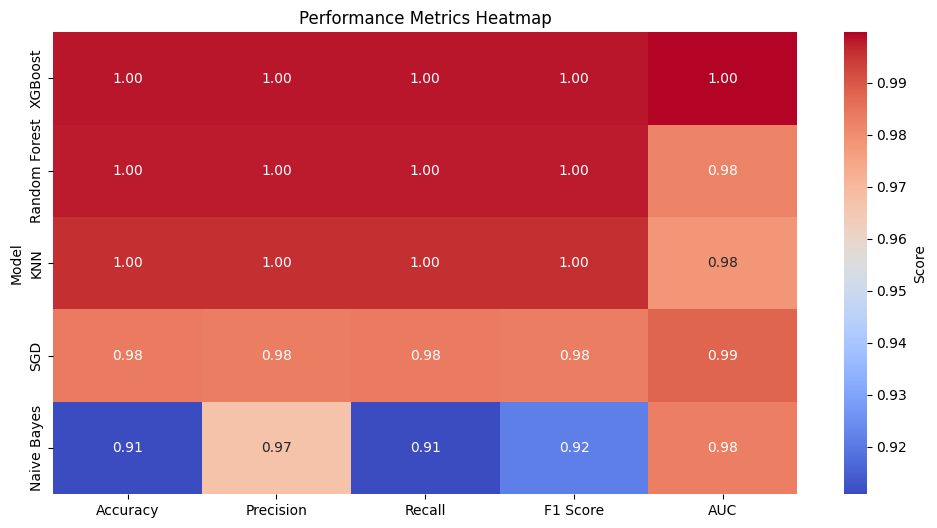

In [10]:
# Step 6: Heatmap of metrics
plt.figure(figsize=(12, 6))
sns.heatmap(results_df.set_index("Model"), annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Score'})
plt.title("Performance Metrics Heatmap")
plt.show()

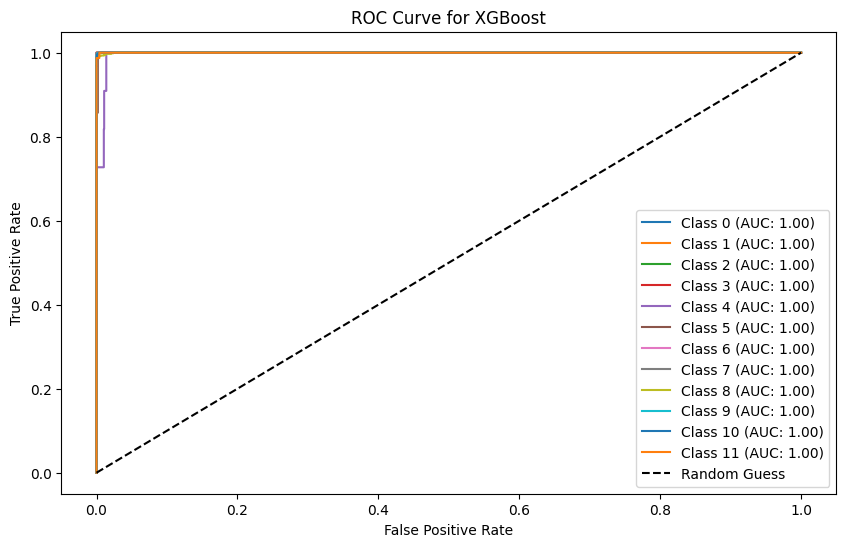

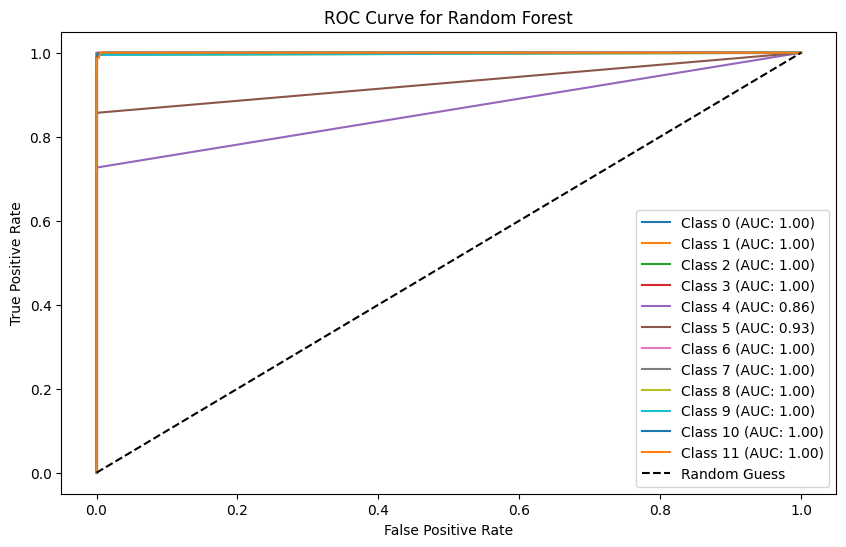

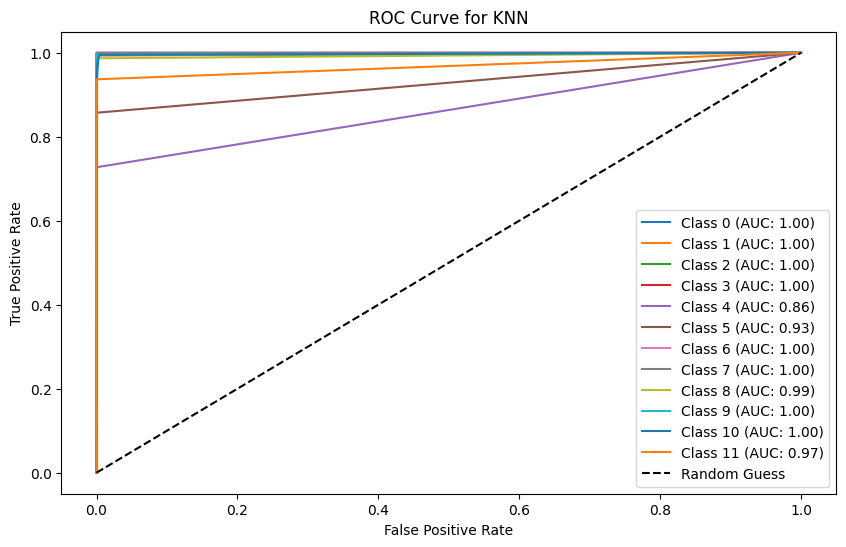

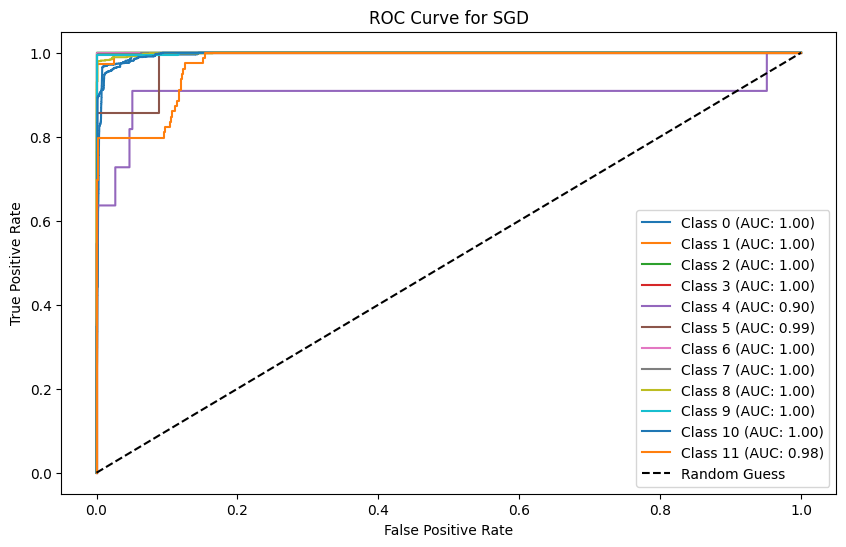

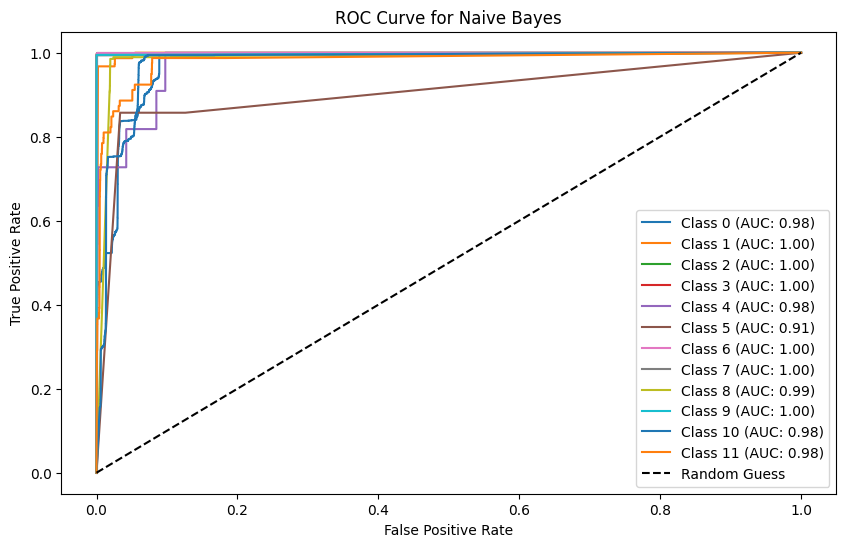

In [11]:
# Import necessary libraries
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Generate and plot ROC curves for each model
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):  # Check if model supports predict_proba
        y_pred_proba = model.predict_proba(X_test)  # Get predicted probabilities

        plt.figure(figsize=(10, 6))
        for i in range(y_test_binarized.shape[1]):  # Iterate through each class
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            auc = roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f"Class {i} (AUC: {auc:.2f})")

        # Plot diagonal reference line
        plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

        # Add titles and labels
        plt.title(f"ROC Curve for {name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="best")
        plt.show()
    else:
        print(f"{name} does not support predict_proba; skipping ROC curve.")


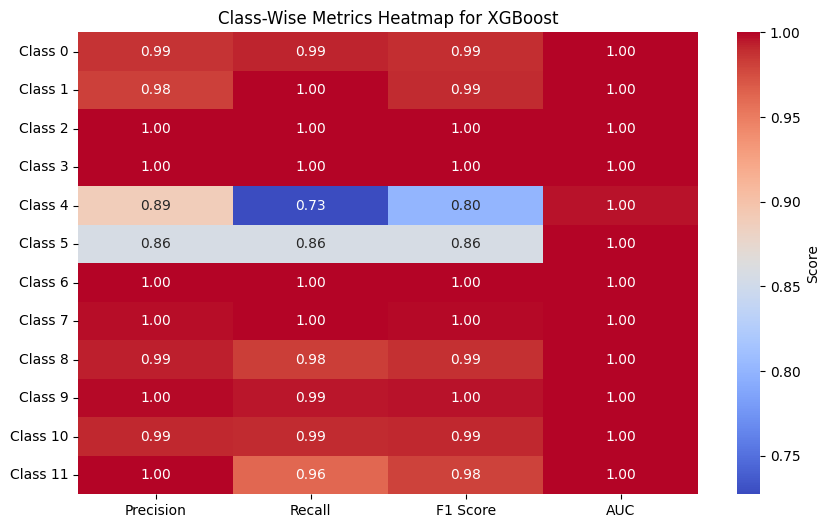

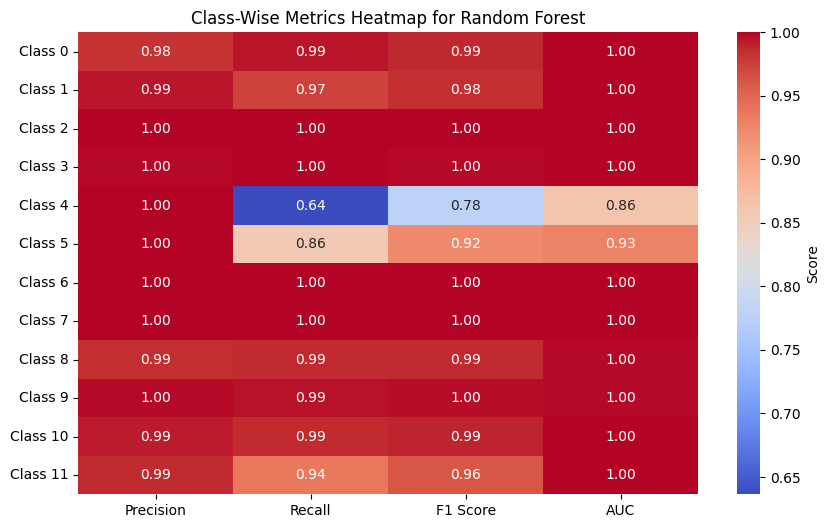

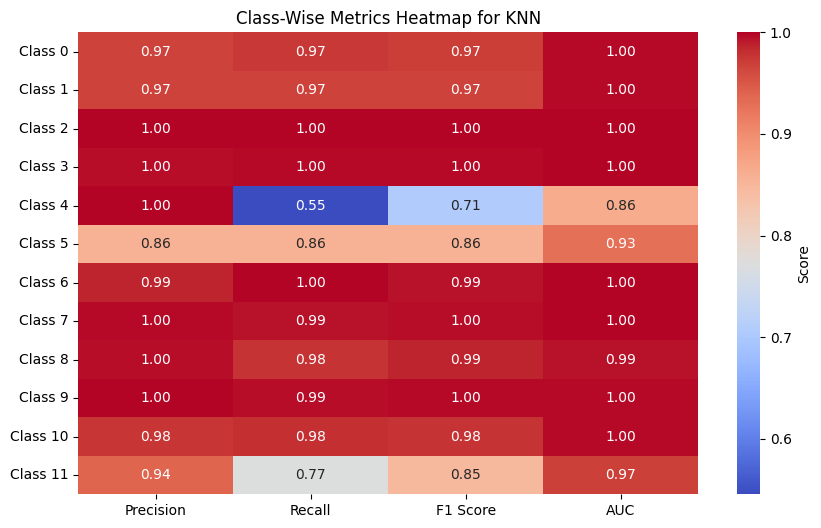

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


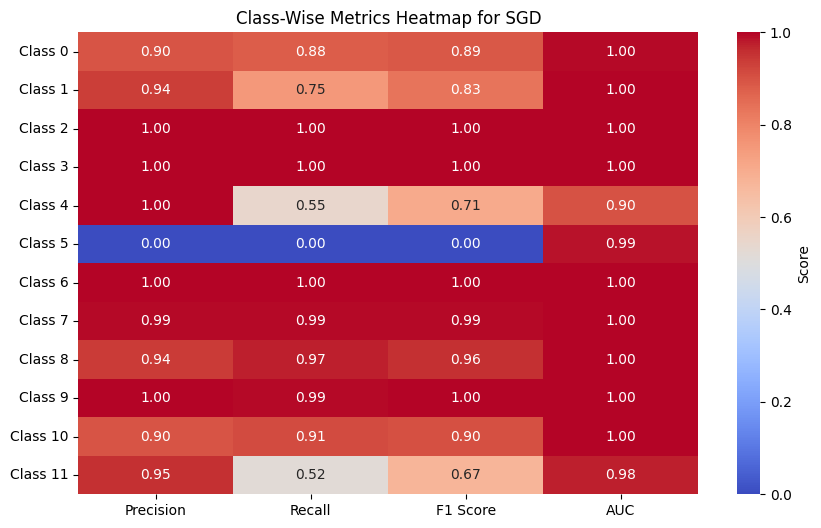

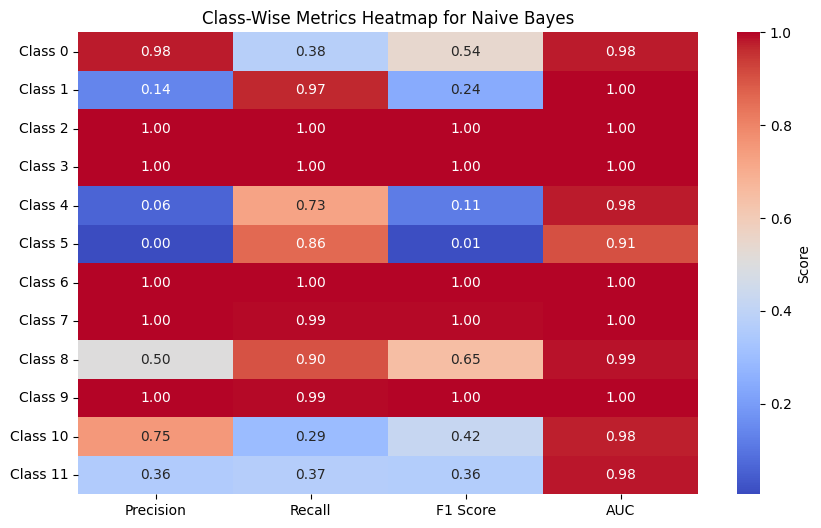

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns

# Generate heatmaps for each model
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)

        # Calculate metrics for each class
        class_metrics = {
            "Precision": precision_score(y_test, y_pred, average=None),
            "Recall": recall_score(y_test, y_pred, average=None),
            "F1 Score": f1_score(y_test, y_pred, average=None),
            "AUC": [roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i]) for i in range(y_test_binarized.shape[1])]
        }

        # Create a DataFrame
        metrics_df = pd.DataFrame(class_metrics)
        metrics_df.index = [f"Class {i}" for i in range(y_test_binarized.shape[1])]

        # Plot the heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(metrics_df, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Score'})
        plt.title(f"Class-Wise Metrics Heatmap for {name}")
        plt.show()
    else:
        print(f"{name} does not support predict_proba; skipping heatmap.")


<Figure size 800x600 with 0 Axes>

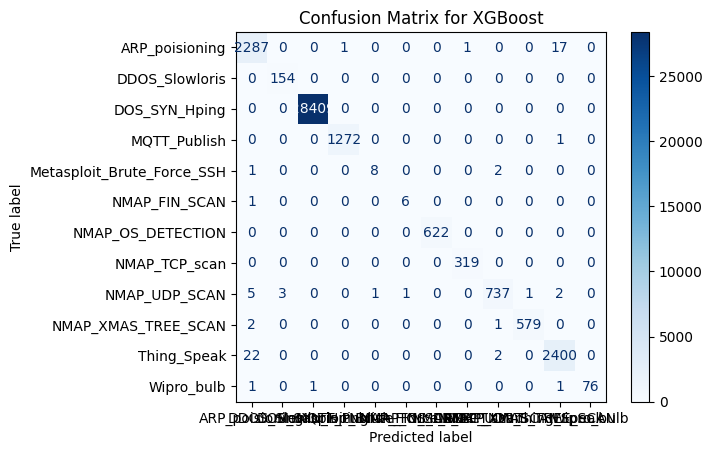

<Figure size 800x600 with 0 Axes>

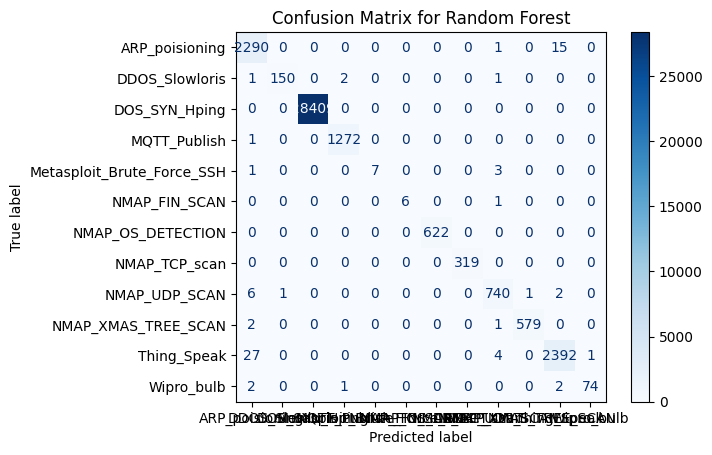

<Figure size 800x600 with 0 Axes>

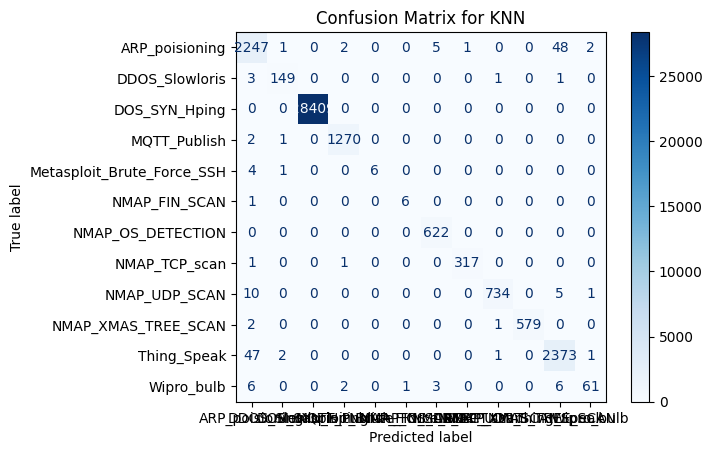

<Figure size 800x600 with 0 Axes>

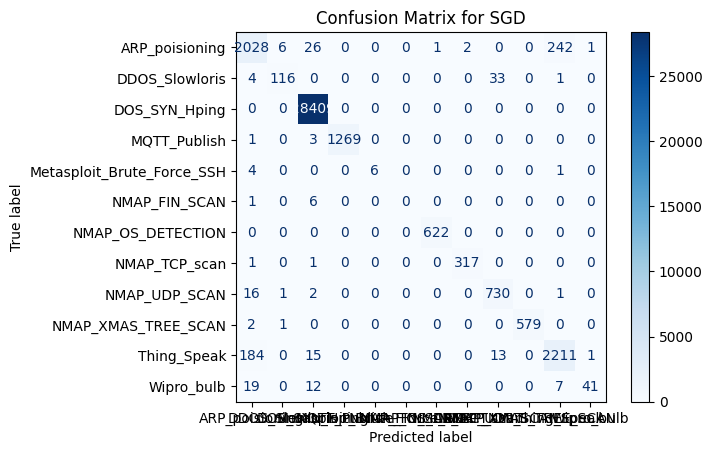

<Figure size 800x600 with 0 Axes>

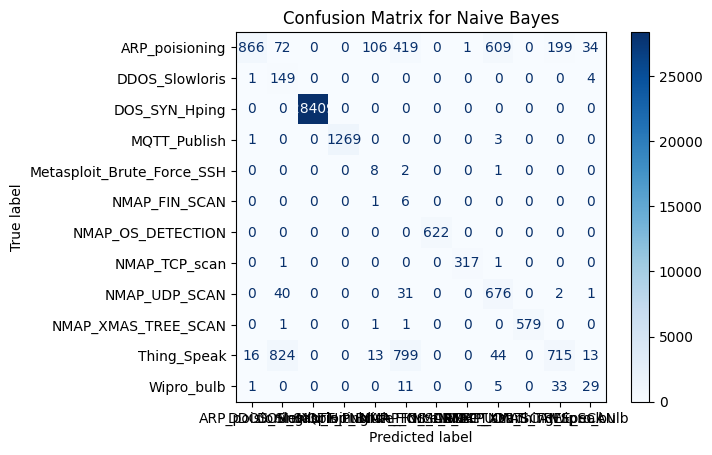

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plot confusion matrices for each model
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

    plt.figure(figsize=(8, 6))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix for {name}")
    plt.show()


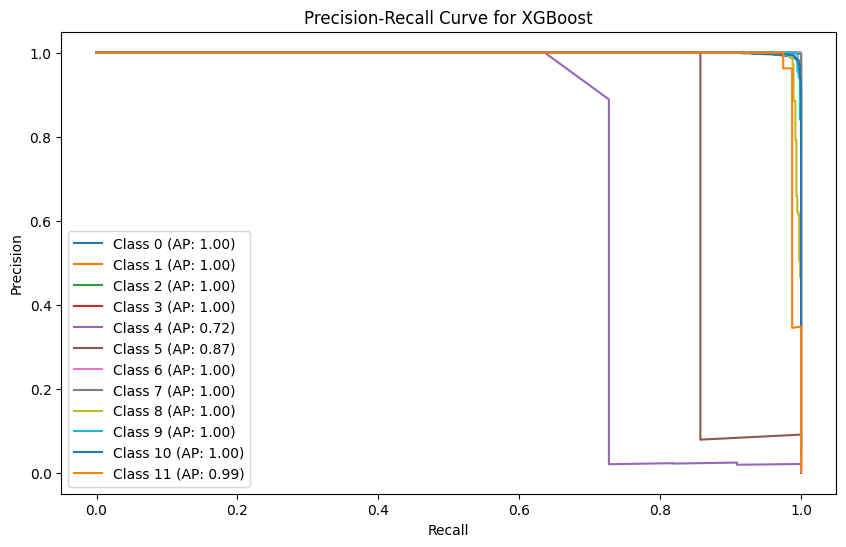

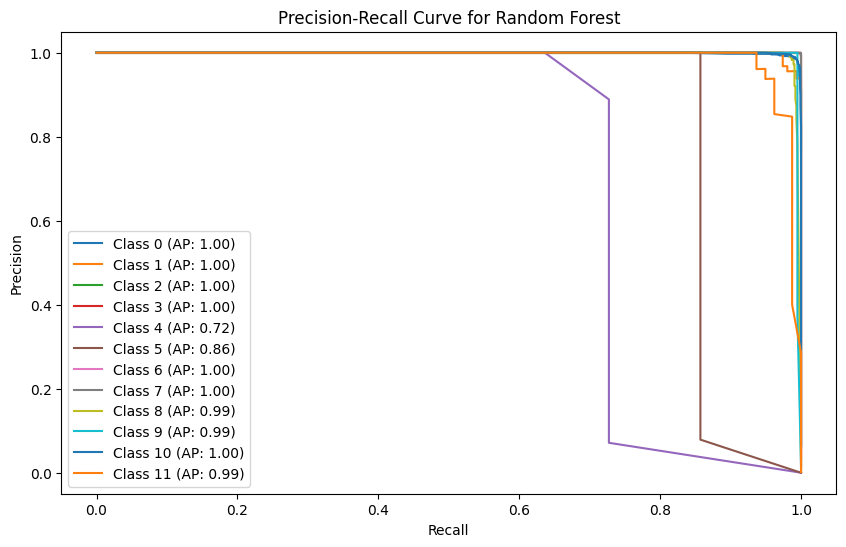

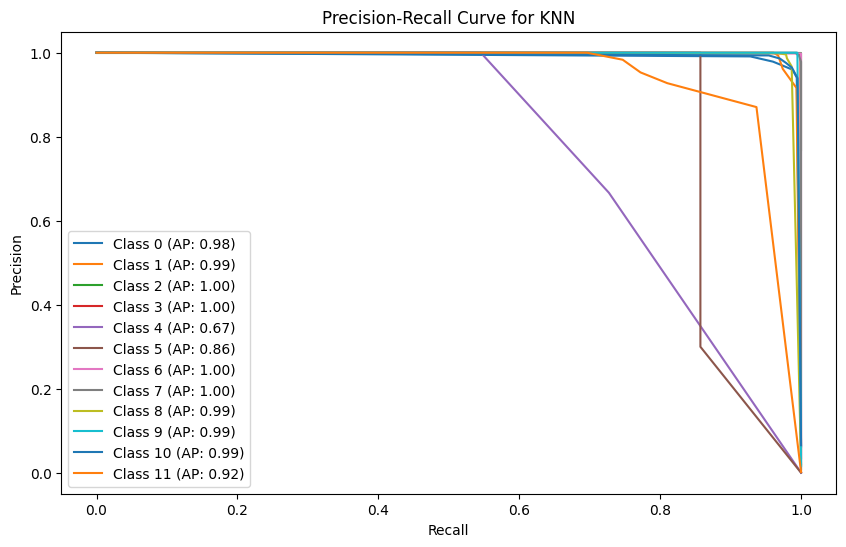

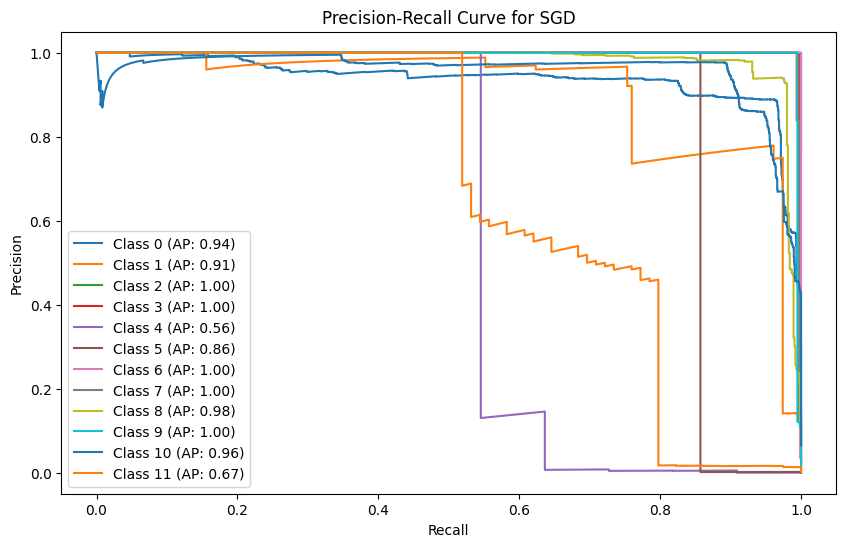

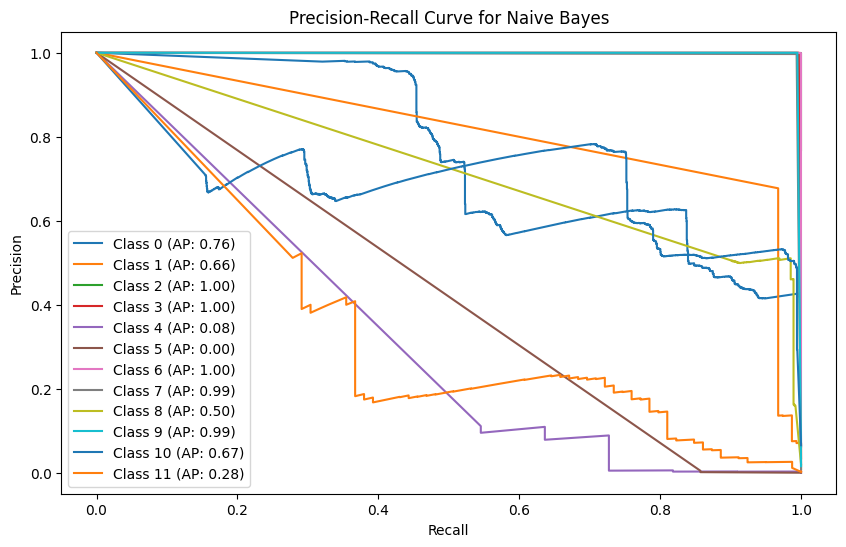

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall curves
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)

        plt.figure(figsize=(10, 6))
        for i in range(y_test_binarized.shape[1]):  # Iterate over classes
            precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            ap = average_precision_score(y_test_binarized[:, i], y_pred_proba[:, i])
            plt.plot(recall, precision, label=f"Class {i} (AP: {ap:.2f})")

        plt.title(f"Precision-Recall Curve for {name}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.legend()
        plt.show()
    else:
        print(f"{name} does not support predict_proba; skipping Precision-Recall curve.")


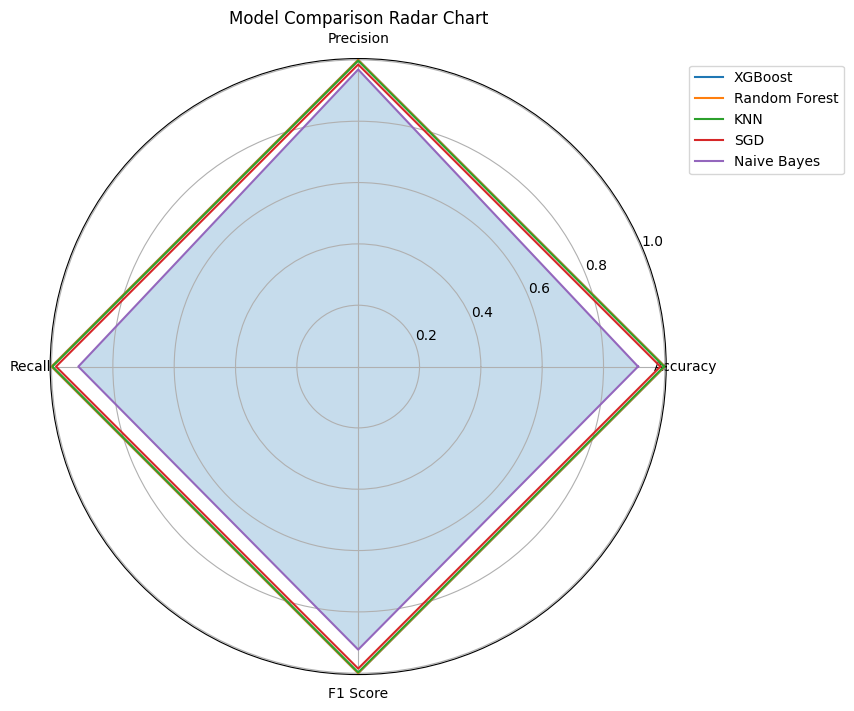

In [16]:
from math import pi

# Prepare data for radar chart
metrics_for_radar = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
radar_df = results_df[metrics_for_radar].set_index(results_df['Model'])

# Normalize metrics to [0, 1] for better visualization
radar_df_normalized = radar_df / radar_df.max()

# Radar chart
labels = radar_df_normalized.columns
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 8))
for i, row in radar_df_normalized.iterrows():
    values = row.tolist()
    values += values[:1]  # Close the radar chart
    plt.polar(angles, values, label=i)

plt.fill(angles, values, alpha=0.25)
plt.title("Model Comparison Radar Chart")
plt.xticks(angles[:-1], labels)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.show()


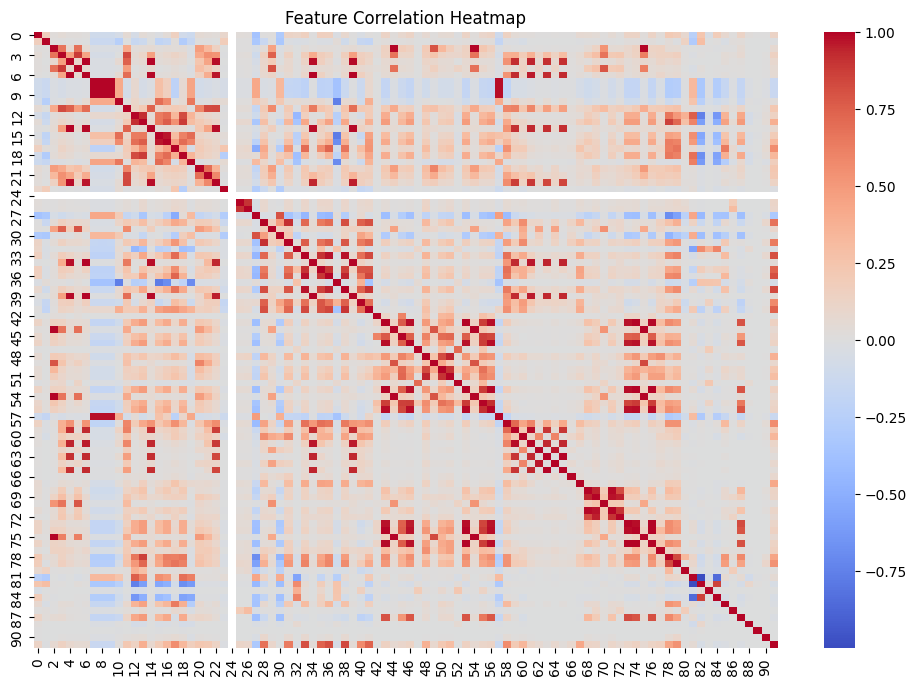

In [18]:
# Correlation heatmap
corr_matrix = pd.DataFrame(X_train).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


<ipython-input-19-cdaab3bed35a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Metric", y="Score", data=results_long, palette="viridis")


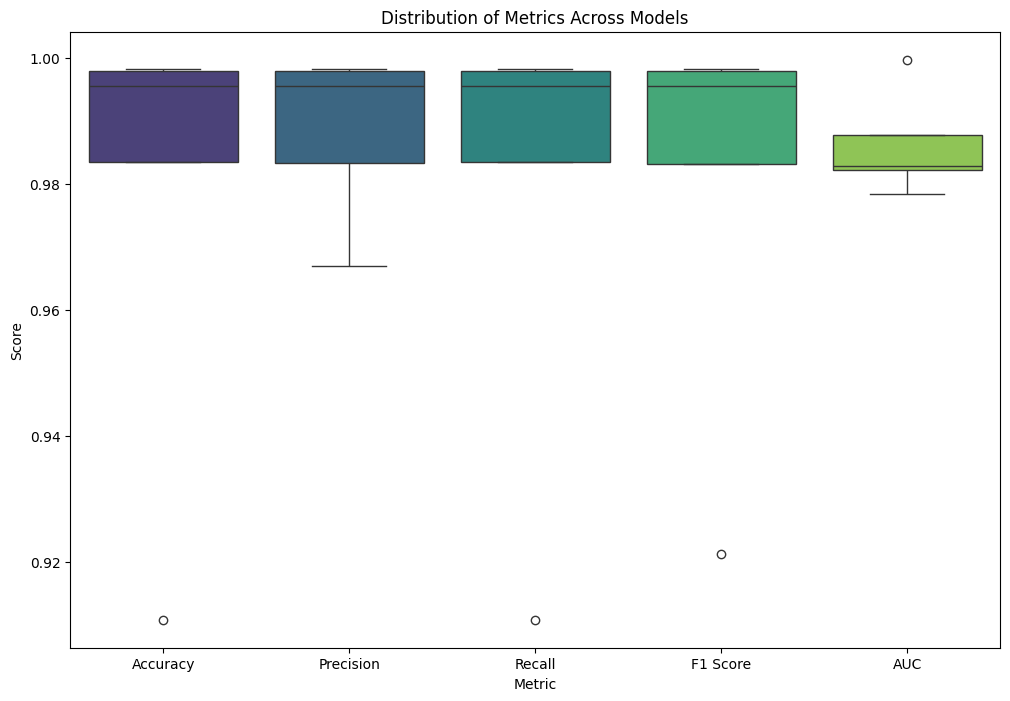

In [19]:
# Boxplot of metrics across models
results_long = results_df.melt(id_vars=["Model"], var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 8))
sns.boxplot(x="Metric", y="Score", data=results_long, palette="viridis")
plt.title("Distribution of Metrics Across Models")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()


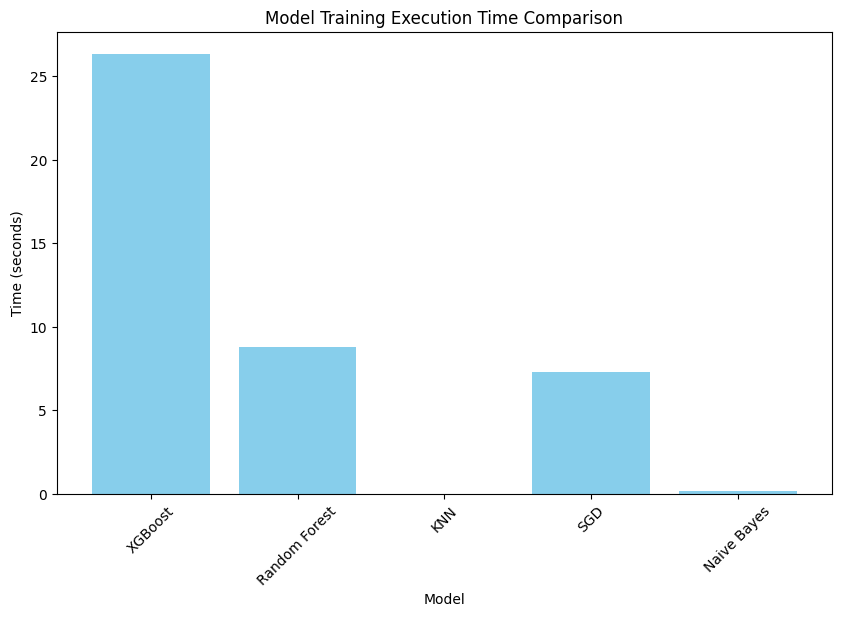

In [20]:
import time

execution_times = {}

# Measure execution time for each model
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    execution_times[name] = elapsed_time

# Plot execution times
plt.figure(figsize=(10, 6))
plt.bar(execution_times.keys(), execution_times.values(), color="skyblue")
plt.title("Model Training Execution Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py", line 1491, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6

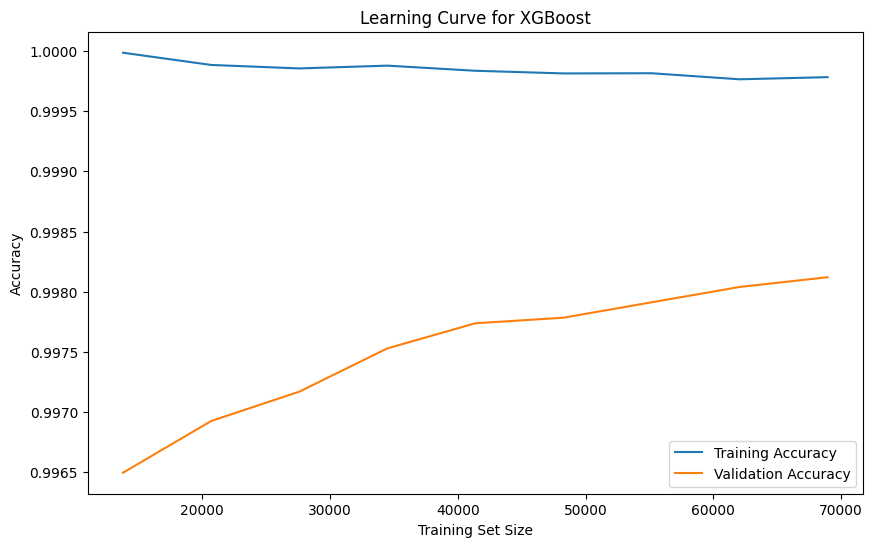

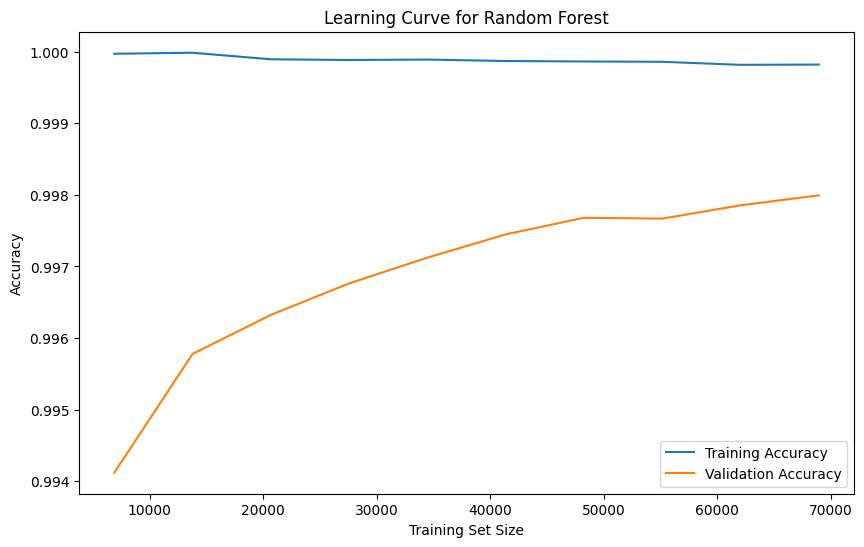

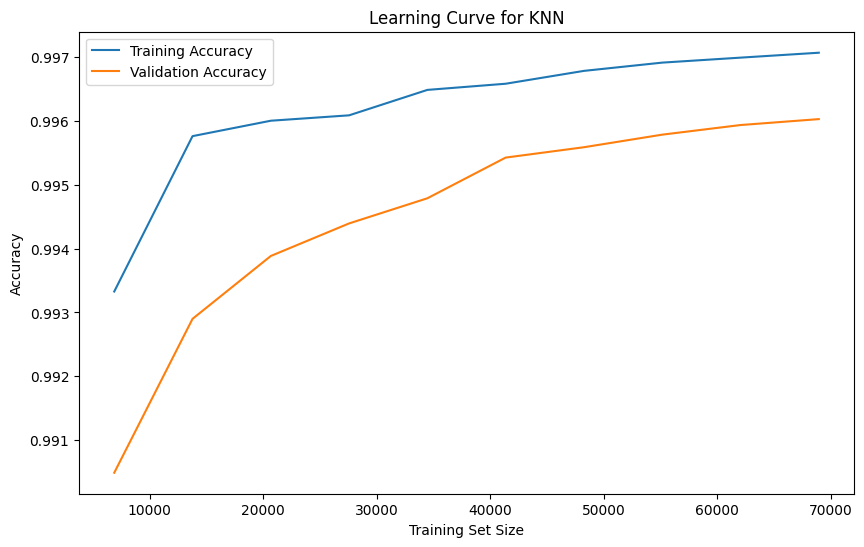

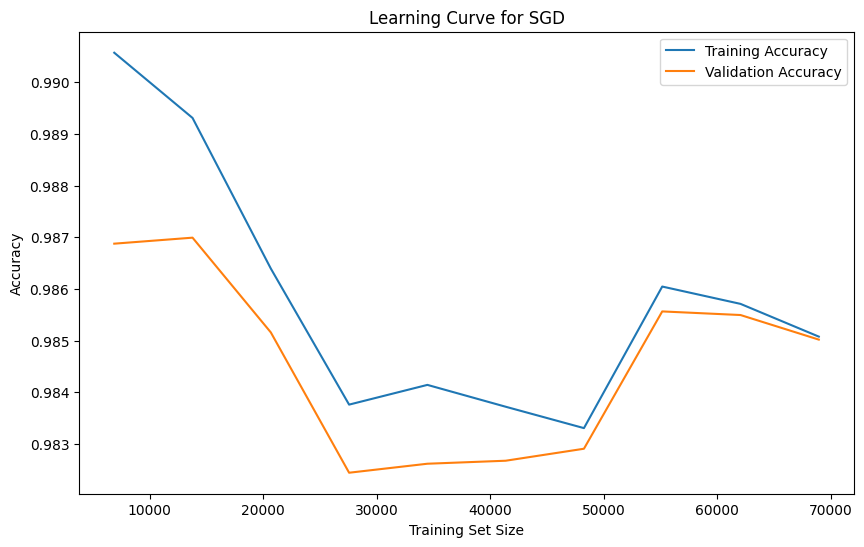

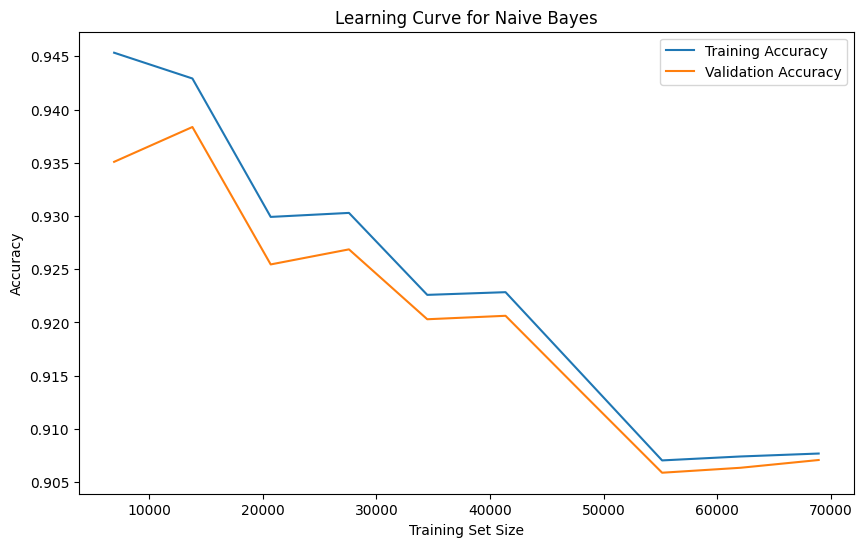

In [25]:
from sklearn.model_selection import learning_curve

for name, model in trained_models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label="Training Accuracy")
    plt.plot(train_sizes, test_mean, label="Validation Accuracy")
    plt.title(f"Learning Curve for {name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


In [23]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize an empty list to store metrics
metrics_results = []

# Loop through each model to calculate metrics
for name, model in trained_models.items():
    y_pred = model.predict(X_test)  # Predict on test set
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
    }
    # Calculate AUC if the model supports predict_proba
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)
        metrics['AUC'] = roc_auc_score(y_test_binarized, y_pred_proba, multi_class='ovr')
    else:
        metrics['AUC'] = 'N/A'  # If AUC is not applicable, mark as 'N/A'

    # Append the metrics dictionary to the results list
    metrics_results.append(metrics)

# Create a DataFrame for better visualization
metrics_table = pd.DataFrame(metrics_results)

# Sort the table by Accuracy for ranking
metrics_table.sort_values(by='Accuracy', ascending=False, inplace=True)

# Display the table
print("Model Metrics Comparison Table:")
print(metrics_table)

# Save the table as CSV (optional)
metrics_table.to_csv("model_metrics_comparison.csv", index=False)


Model Metrics Comparison Table:
           Model  Accuracy  Precision    Recall  F1 Score       AUC
0        XGBoost  0.998186   0.998184  0.998186  0.998180  0.999690
1  Random Forest  0.997942   0.997949  0.997942  0.997929  0.982182
2            KNN  0.995587   0.995586  0.995587  0.995546  0.978446
3            SGD  0.985191   0.984906  0.985191  0.984829  0.986778
4    Naive Bayes  0.910900   0.966957  0.910900  0.921368  0.982881


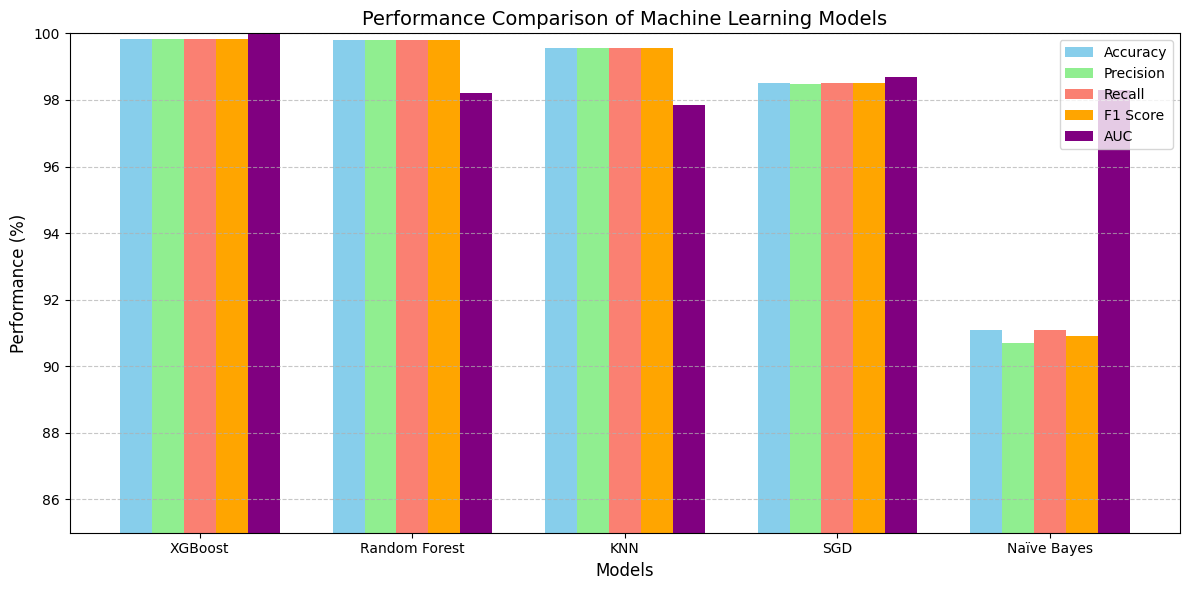

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['XGBoost', 'Random Forest', 'KNN', 'SGD', 'Naïve Bayes']
accuracy = [99.82, 99.79, 99.56, 98.52, 91.09]
precision = [99.82, 99.79, 99.56, 98.49, 90.70]
recall = [99.82, 99.79, 99.56, 98.52, 91.10]
f1_score = [99.82, 99.79, 99.56, 98.51, 90.90]
auc = [99.97, 98.22, 97.84, 98.68, 98.29]

# Set bar width and positions
bar_width = 0.15
x = np.arange(len(models))

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - 2*bar_width, accuracy, bar_width, label='Accuracy', color='skyblue')
plt.bar(x - bar_width, precision, bar_width, label='Precision', color='lightgreen')
plt.bar(x, recall, bar_width, label='Recall', color='salmon')
plt.bar(x + bar_width, f1_score, bar_width, label='F1 Score', color='orange')
plt.bar(x + 2*bar_width, auc, bar_width, label='AUC', color='purple')

# Add labels and title
plt.xlabel('Models', fontsize=12)
plt.ylabel('Performance (%)', fontsize=12)
plt.title('Performance Comparison of Machine Learning Models', fontsize=14)
plt.xticks(x, models)
plt.ylim(85, 100)
plt.legend()

# Show grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [27]:
!apt-get install graphviz
!pip install graphviz

from graphviz import Digraph

# Initialize the Digraph
dot = Digraph(format='png', engine='dot')
dot.attr(rankdir='TB', size='8,10')

# Add Nodes
dot.node('A', 'Input Dataset', shape='rectangle', style='filled', color='lightblue')
dot.node('B', 'Data Preprocessing', shape='rectangle', style='filled', color='lightgreen')
dot.node('B1', 'Data Cleaning', shape='ellipse', style='filled', color='lightyellow')
dot.node('B2', 'Feature Selection', shape='ellipse', style='filled', color='lightyellow')
dot.node('B3', 'Data Normalization', shape='ellipse', style='filled', color='lightyellow')
dot.node('C', 'Split Dataset\n(Training 80%, Testing 20%)', shape='rectangle', style='filled', color='lightgreen')

# Add Nodes for Models
models = {
    'D1': 'XGBoost\n(Gradient Boosting)',
    'D2': 'Random Forest\n(Decision Tree Ensemble)',
    'D3': 'KNN\n(Nearest Neighbors)',
    'D4': 'SGD\n(Gradient Descent)',
    'D5': 'Naïve Bayes\n(Probabilistic Classification)',
}
for model, label in models.items():
    dot.node(model, label, shape='rectangle', style='filled', color='orange')

# Add Nodes for Evaluation Metrics
metrics = {
    'E1': 'Model Evaluation\n(Metrics Calculation)',
    'E2': 'Accuracy',
    'E3': 'Precision',
    'E4': 'Recall',
    'E5': 'F1 Score',
    'E6': 'ROC and AUC',
}
for metric, label in metrics.items():
    dot.node(metric, label, shape='ellipse', style='filled', color='lightpink')

# Add Nodes for Results and Future Work
dot.node('F', 'Performance Comparison', shape='rectangle', style='filled', color='lightblue')
dot.node('G', 'Results and Analysis', shape='rectangle', style='filled', color='lightblue')
dot.node('H', 'Conclusion', shape='rectangle', style='filled', color='lightblue')
dot.node('I', 'Future Work', shape='rectangle', style='filled', color='lightblue')

# Add Edges
dot.edges(['AB', 'BB1', 'BB2', 'BB3', 'BC'])
dot.edges(['CD1', 'CD2', 'CD3', 'CD4', 'CD5'])
dot.edges(['D1E1', 'D2E1', 'D3E1', 'D4E1', 'D5E1'])
dot.edges(['E1E2', 'E1E3', 'E1E4', 'E1E5', 'E1E6'])
dot.edges(['E2F', 'E3F', 'E4F', 'E5F', 'E6F'])
dot.edges(['FG', 'GH', 'HI'])

# Render and Display the Graph
dot.render('flowchart', format='png', cleanup=True)
from IPython.display import Image
Image('flowchart.png')



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
